# real_groundtruth_multiregion.ipynb

Multi-region version of `real_groundtruth_downscale.ipynb`.

The four-scene protocol is a case study: tens of thousands of HEALPix cells,
but **four patches and one sensor**. This notebook runs the *same seven steps*
on **real Sentinel-2 patches at the 40 region anchors** already used by the
synthetic multi-region validation, so the real-data claim gets the same
statistical treatment as the synthetic one.

Note these are **Sentinel-2** acquisitions, not the Esri textures the
synthetic multi-region validation uses. They reuse only the *site list*.

**Statistical unit is the region.** One patch per region, ten regions per
scene class. The bootstrap below therefore resamples 10 independent values per
class -- a plain bootstrap over regions, not a cluster bootstrap (with a single
patch per region there is no within-region clustering left to absorb).

**Protocol** (identical to the four-scene notebook, see
`tests/real_groundtruth_common_tools.py`):

1. fetch a real, native 10 m Sentinel-2 B04 patch at the region anchor
2. PSF-aware resample the undegraded data to `NATIVE_LEVEL` (20)
3. plain no-PSF NESTED downgrade to `REF_LEVEL` (19) -- **the reference**
4. Gaussian-blur to the coarse effective resolution (FWHM 25 m)
5. point-sample every `BLOCK`-th pixel (20 m observation)
6. PSF-aware resample the coarse samples onto `REF_LEVEL`
7. compare against the reference, cell-for-cell, at `REF_LEVEL`

## Input data

The 40 patches are a **primary input**, archived like every other one:

```text
notebooks/data/multi_patch_sentinel2/region__<class>__<region_id>_data.zarr
```

They are covered by `notebooks/build_data_manifest.py`, so a normal run reads
them offline. Install the bundle with `load_data_in_zenodo.ipynb` first.

If they are not in the published archive yet, build them once with the
acquisition cell below, then rebuild the manifest and publish a new DOI.

**Prerequisite**: `tables/multi_patch_sites.csv` (written by
`multi_patch_latitude_validation.ipynb`) supplies the site list.

## Setup

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=None, marker="healpix_resample"):
    """Walk upward until a directory containing `marker` is found."""
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repo root above {p}.")


REPO_ROOT = find_repo_root()
MODULE_PATH = REPO_ROOT / "tests" / "real_groundtruth_common_tools.py"
print("module:", MODULE_PATH, "(exists:", MODULE_PATH.exists(), ")")

spec = importlib.util.spec_from_file_location("real_groundtruth_common_tools", MODULE_PATH)
gt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gt)

gt.describe_config()


module: /home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py (exists: True )
NATIVE_LEVEL=20: cell size ~= 6.22 m (reference built from real 10 m data, step 2)
REF_LEVEL=19:    cell size ~= 12.44 m (comparison level for every method, vs. 20 m coarse/degraded pixel, step 7)
DEGRADE_PSF_MODE='isotropic': FWHM_x=25.0 m, FWHM_y=25.0 m; isotropic reconstruction FWHM=25.0 m
EDGE_MARGIN_M=200 m excluded from every metric
REFERENCE_MODE='psf_aware', BASELINE_ESTIMAND='cell_average', MAX_ITER=14


## Step 0 -- register the 40 regions

One patch per region, taken at lattice position (1, 1), i.e. the region anchor
itself. The patch is chosen by **position, before any data is fetched or
scored**, so the selection cannot depend on the results.

In [2]:
scenes = gt.load_region_sites()          # patch_row=patch_col=1 by default
print(f"\n{len(scenes)} scenes registered, e.g.:")
for s in scenes[:3]:
    c = gt.region_coordinates[s]
    print(f"  {s:44s} {c['location']:22s} "
          f"lat={c['wgs84']['lat']:7.3f} lon={c['wgs84']['lon']:8.3f}")


Registered 40 regions (4 classes, {'urban': 10, 'water': 10, 'forest': 10, 'agriculture': 10}); 9 candidate patch position(s) each.

40 scenes registered, e.g.:
  region__urban__singapore                     Singapore              lat=  1.290 lon= 103.852
  region__urban__nairobi                       Nairobi, Kenya         lat= -1.286 lon=  36.817
  region__urban__sao_paulo                     Sao Paulo, Brazil      lat=-23.550 lon= -46.633


## Step 1 -- locate the Sentinel-2 patches

Read-only check against the frozen bundle. Nothing is downloaded here.

In [3]:
present = gt.check_region_sites()
available = present.loc[present.present, "scene"].tolist()
display(present[~present.present])
print(f"{len(available)} / {len(present)} region patches usable.")


40/40 region patches present under data/multi_patch_sentinel2.


,scene,path,present


40 / 40 region patches usable.


### One-off: building the bundle (skip if the archive already has it)

`acquire_region_sites()` is the only network call in this notebook and exists
to *construct* an input bundle, not to run an experiment. Run it once, then
rebuild the manifest and publish a new Zenodo version, then set `OFFLINE` back
to `True` so every later run reads archived copies.

A region with no cloud-free acquisition in `gt.REGION_DATE_WINDOW` fails here
and is skipped downstream -- a data-availability criterion, evaluated long
before any method is scored.

#### Preflight: the COG reader

The 40 region patches come from **Element 84's earth-search**, which holds the
complete Sentinel-2 L2A archive as Cloud-Optimized GeoTIFFs, so the same 40
sites as the synthetic validation are all reachable.

The EOPF STAC used for the four paper scenes is a European demonstration
catalogue: queried at these anchors it returned nothing outside Europe and
part of North America -- Amazon, Borneo, Congo, Punjab, Pampas, Tokyo,
Singapore and most of the southern hemisphere all gave `No items` even with a
four-year window at 40% cloud. That is coverage, not weather, so no filter
change could fix it.

Reading COGs needs `rasterio` (declared in the `notebooks` pixi feature):

    pixi run -e notebooks jupyter lab

In [4]:
print("source:", gt.REGION_STAC_SOURCE)
try:
    import rasterio
    print("rasterio", rasterio.__version__, "->", rasterio.__file__)
except ImportError as exc:
    print(f"rasterio is NOT importable ({exc}).\n"
          "Run this notebook with:  pixi run -e notebooks jupyter lab\n"
          "Avoid `!pip install` inside a pixi environment: a PyPI wheel "
          "shadowing conda's libproj is what breaks PROJ and the eopf-zarr "
          "backend (see the warning in pixi.toml).")


source: earth-search
rasterio 1.5.0 -> /srv/conda/envs/notebook/lib/python3.13/site-packages/rasterio/__init__.py


In [5]:
# Leave this cell unexecuted for a normal, offline run.
RUN_ACQUISITION = False

# Provenance first, download second. The bundle was built in two passes -- the
# EOPF demonstration catalogue, then earth-search once EOPF turned out to
# cover only Europe and North America -- so some stores can still carry the
# first pass's endpoint, product and radiometric convention. A blanket
# force=True would re-download all 40 and change every product id, discarding
# 38 perfectly good patches (and the paper's numbers with them). Re-acquiring
# only the heterogeneous stores keeps the change auditable.
prov = gt.region_provenance()
needs_refetch = prov.attrs["needs_refetch"]

if RUN_ACQUISITION:
    gt.OFFLINE = False
    status = gt.acquire_region_sites(scenes=needs_refetch or None,
                                     force=bool(needs_refetch), screen=True)
    gt.OFFLINE = True
    display(status[status.status != "ok"])
    print("\nNow, from the repository root:")
    print("  python notebooks/build_data_manifest.py --doi <new DOI>")
    print("  python notebooks/build_data_manifest.py --check --doi <new DOI>")
    present = gt.check_region_sites()
    available = present.loc[present.present, "scene"].tolist()
    gt.region_provenance()          # confirm the bundle is now homogeneous
else:
    print("Acquisition skipped; using the frozen bundle.")


Provenance: 36/40 stores come from earth-search (https://earth-search.aws.element84.com/v1).
  region__forest__black_forest               https://stac.core.eopf.eodc.eu
  region__forest__finland_boreal             https://stac.core.eopf.eodc.eu
  region__water__lake_constance              https://stac.core.eopf.eodc.eu
  region__water__lake_geneva                 https://stac.core.eopf.eodc.eu

To make provenance homogeneous, re-acquire exactly these:
  gt.acquire_region_sites(scenes=needs_refetch, force=True)
Then rebuild the manifest and re-run the protocol: the product ids change, so the paper's numbers must be re-derived rather than patched.
Acquisition skipped; using the frozen bundle.


## Input-quality screen

The STAC cloud filter is a **scene-level** percentage: a granule reported at
8% cloud can still have our 2.56 km patch entirely under a cloud, and a patch
near a granule edge can be mostly no-data. Both would enter the experiment
looking perfectly legitimate.

Every criterion below reads **only the input patch** -- never a reconstruction
or a score -- and runs before any method, so screening cannot favour any
method. Rejections go to `tables/real_groundtruth_multiregion_quality.csv`.

| Criterion | Threshold | Catches |
|---|---|---|
| shape | full `CENTRAL_SIZE` | patch clipped at a granule edge |
| finite fraction | `MIN_FINITE_FRACTION` = 0.99 | no-data holes |
| relative std | `MIN_RELATIVE_STD` = 1e-3 | flat patch, degenerate reference |
| bright fraction | `MAX_BRIGHT_FRACTION` = 0.30 above 0.30 reflectance | cloud or snow over the patch |

In [6]:
usable, quality = gt.screen_region_patches(available)
display(quality[["scene", "shape", "finite_fraction", "relative_std",
                 "bright_fraction", "usable", "flags"]])


40/40 patches pass the input-quality screen.

Per class among the usable patches:
  agriculture     10
  forest          10
  urban           10
  water           10


,scene,shape,finite_fraction,relative_std,bright_fraction,usable,flags
0,region__agriculture__beauce,256x256,1.000000,0.567459,0.169083,True,
1,region__agriculture__canterbury,256x256,1.000000,0.663296,0.000031,True,
2,region__agriculture__iowa,256x256,1.000000,0.545096,0.000275,True,
3,region__agriculture__mato_grosso,256x256,1.000000,0.164511,0.002304,True,
4,region__agriculture__nile_delta,256x256,1.000000,0.258868,0.117920,True,
5,region__agriculture__pampas,256x256,1.000000,0.662380,0.006439,True,
6,region__agriculture__po_valley,256x256,1.000000,0.329124,0.000076,True,
7,region__agriculture__punjab,256x256,1.000000,0.541817,0.000275,True,
8,region__agriculture__ukraine,256x256,1.000000,0.433206,0.000565,True,
9,region__agriculture__western_australia,256x256,1.000000,0.355075,0.000000,True,


## Steps 2-7 -- run the protocol on every region

Same code path as the four-scene notebook: `run_all()` per scene, then the
per-region rows are concatenated with their scene class and region id.

In [7]:
metrics, failures = gt.run_multiregion(scenes=usable, force=False)

print()
print(metrics.groupby("scene_class").region_id.nunique().rename("regions").to_string())
display(failures)


[  1/40] region__agriculture__beauce: 5 rows
[  2/40] region__agriculture__canterbury: 5 rows
[  3/40] region__agriculture__iowa: 5 rows
[  4/40] region__agriculture__mato_grosso: 5 rows
[  5/40] region__agriculture__nile_delta: 5 rows
[  6/40] region__agriculture__pampas: 5 rows
[  7/40] region__agriculture__po_valley: 5 rows
[  8/40] region__agriculture__punjab: 5 rows
[  9/40] region__agriculture__ukraine: 5 rows
[ 10/40] region__agriculture__western_australia: 5 rows
[ 11/40] region__forest__amazon: 5 rows
[ 12/40] region__forest__appalachian: 5 rows
[ 13/40] region__forest__black_forest: 5 rows
[ 14/40] region__forest__borneo: 5 rows
[ 15/40] region__forest__canadian_rockies: 5 rows
[ 16/40] region__forest__congo: 5 rows
[ 17/40] region__forest__finland_boreal: 5 rows
[ 18/40] region__forest__new_zealand: 5 rows
[ 19/40] region__forest__patagonia: 5 rows
[ 20/40] region__forest__tasmania: 5 rows
[ 21/40] region__urban__cape_town: 5 rows
[ 22/40] region__urban__mexico_city: 5 rows


""


### Evaluated-cell screen

The input-quality screen looks at the patch. Nothing yet looked at how many
HEALPix cells the *protocol* actually managed to score. A region whose
reference and reconstruction barely overlap can pass the input screen and
still contribute a handful of cells -- then carry the same weight as a full
region in the region-level mean -- or contribute none at all and silently
shrink every paired comparison.

`n_cells` is identical across all five methods within a region, so this
criterion cannot favour any method.

In [8]:
metrics, dropped_regions = gt.screen_region_metrics(metrics)
if len(dropped_regions):
    display(dropped_regions[["region_id", "scene_class", "method",
                             "n_cells", "rmse"]])


Evaluated-cell screen: median 29,906 cells per region, floor 14,953 (50%).
  2 region(s) dropped:
    agriculture  nile_delta           448 cells (1.5% of median)
    agriculture  western_australia    no evaluable cells
  38 region(s) retained.
  Run diagnose_alignment(sorted(bad)) to see WHICH stage of the geometry collapsed before accepting the loss.


,region_id,scene_class,method,n_cells,rmse
20,nile_delta,agriculture,psf_aware,448,0.040521
21,nile_delta,agriculture,classical_nearest,448,0.048275
22,nile_delta,agriculture,classical_linear,448,0.046502
23,nile_delta,agriculture,classical_cubic,448,0.057041
24,nile_delta,agriculture,richardson_lucy,448,0.104622
45,western_australia,agriculture,psf_aware,0,NaN
46,western_australia,agriculture,classical_nearest,0,NaN
47,western_australia,agriculture,classical_linear,0,NaN
48,western_australia,agriculture,classical_cubic,0,NaN
49,western_australia,agriculture,richardson_lucy,0,NaN


### Why a region was dropped

`screen_region_metrics` reports *that* a region evaluated too few cells. It
cannot say *why*, and "the two supports did not overlap" is a description
rather than a diagnosis. Since `n_cells` is identical across all five methods,
the loss happens in the one code path they share, and that path has only four
stages. The cell below measures all four, so a dropped region is a diagnosed
fact rather than an accepted casualty -- and so that the fix, if there is one,
is aimed at the right stage.


In [9]:
# Read-only and cache-backed: no download, no re-solve.
lost = sorted(set(dropped_regions.scene)) if len(dropped_regions) else []
if lost:
    alignment = gt.diagnose_alignment(lost)
    display(alignment)
else:
    alignment = None
    print("No region dropped by the evaluated-cell screen.")


region__agriculture__nile_delta
    ref   1,562  -> in_ref   1,562  -> interior     448  -> finite     448
    centre offset (+1,090, -0) m in a 2,550 x 2,550 m box
    -> georeferencing: cell centres offset 1,090 m from a 1,275 m half-box
region__agriculture__western_australia
    ref  42,975  -> in_ref  42,975  -> interior       0  -> finite       0
    centre offset (+4,002, -6) m in a 2,550 x 2,550 m box
    -> georeferencing: cell centres offset 4,002 m from a 1,275 m half-box


,scene,n_ref,n_in_ref,n_interior,n_finite,offset_x_m,offset_y_m,box_w_m,box_h_m,verdict
0,region__agriculture__nile_delta,1562,1562,448,448,1090.027750,-0.239583,2550.0,2550.0,"georeferencing: cell centres offset 1,090 m fr..."
1,region__agriculture__western_australia,42975,42975,0,0,4001.629969,-5.809514,2550.0,2550.0,"georeferencing: cell centres offset 4,002 m fr..."


## How many regions survived, and what that allows

Sentinel-2 availability, not statistics, sets the sample size here. Below
`gt.MIN_REGIONS_FOR_CI` regions a per-class bootstrap interval describes
*which sites happened to be usable*, not the class, so it is suppressed and
the class mean is reported as descriptive only.

In [10]:
availability = gt.region_availability(metrics)
display(availability)


38 regions analysed. Per-class breakdown:
  agriculture      8
  forest          10
  urban           10
  water           10


,scene_class,n_regions,per_class_ci_reportable
0,agriculture,8,True
1,forest,10,True
2,urban,10,True
3,water,10,True


### Primary statistic: pooled paired comparison

Every region counts once; each competitor is paired against PSF-aware *within
the same region*, so between-site scene variability cancels. The sign test is
exact and distribution-free, which is what this sample size calls for.

**This is the number to quote in the paper.**

In [11]:
pooled = gt.paired_summary(metrics)
display(pooled)

for _, r in pooled.iterrows():
    print(f"vs {r.competitor:20s} {int(r.psf_aware_wins):2d}/{int(r.n_regions):2d}"
          f"   sign-test p={r.sign_test_p:.3g}"
          f"   mean delta={r.mean_delta_rmse:+.5f} "
          f"[{r.delta_ci95_low:+.5f}, {r.delta_ci95_high:+.5f}]")


,competitor,n_regions,psf_aware_wins,win_fraction,sign_test_p,mean_delta_rmse,delta_ci95_low,delta_ci95_high
0,classical_cubic,38,38,1.0,7.275958e-12,0.004092,0.002851,0.005413
1,classical_linear,38,38,1.0,7.275958e-12,0.005499,0.003833,0.007299
2,classical_nearest,38,38,1.0,7.275958e-12,0.005010,0.003487,0.006674
3,richardson_lucy,38,38,1.0,7.275958e-12,0.002418,0.001644,0.003278


vs classical_cubic      38/38   sign-test p=7.28e-12   mean delta=+0.00409 [+0.00285, +0.00541]
vs classical_linear     38/38   sign-test p=7.28e-12   mean delta=+0.00550 [+0.00383, +0.00730]
vs classical_nearest    38/38   sign-test p=7.28e-12   mean delta=+0.00501 [+0.00349, +0.00667]
vs richardson_lucy      38/38   sign-test p=7.28e-12   mean delta=+0.00242 [+0.00164, +0.00328]


### The pooled result, as a figure

Left: one point per region, PSF-aware against each competitor, log-log with
the 1:1 line -- every point above the line is a region PSF-aware wins. Right:
mean paired difference with bootstrap interval, annotated with wins/n and the
exact sign test.

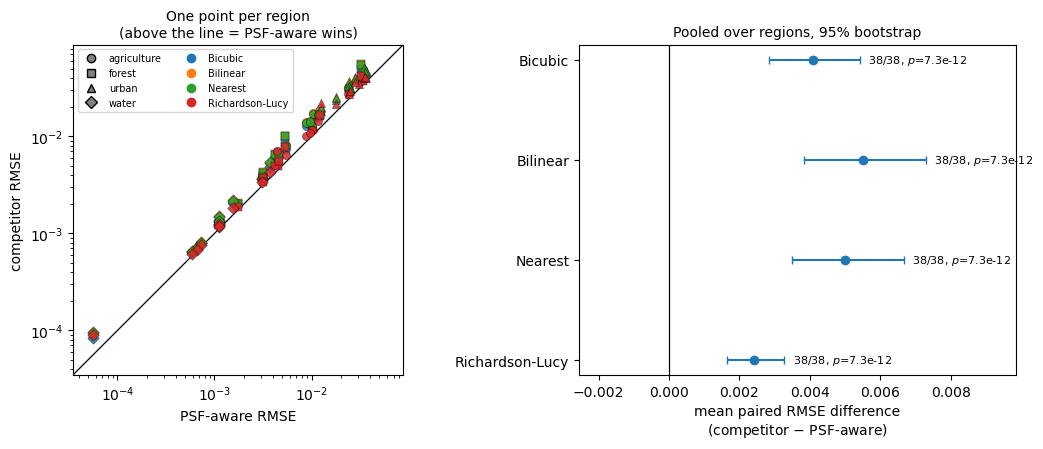

In [12]:
fig = gt.plot_paired_summary(metrics, pooled)


### Secondary: per-class breakdown (descriptive where n is small)

## Region-level aggregation

Per scene class: mean RMSE per method over regions with a percentile bootstrap
interval, and the paired per-region difference against PSF-aware.

In [13]:
summary, comparisons = gt.summarize_multiregion(metrics)
display(summary)


,scene_class,method,n_regions,mean_rmse,rmse_ci95_low,rmse_ci95_high,ci_reportable,between_region_sd
0,agriculture,classical_cubic,8,0.014142,0.009987,0.019593,True,0.007388
1,agriculture,classical_linear,8,0.015483,0.011013,0.021269,True,0.007838
2,agriculture,classical_nearest,8,0.015114,0.010778,0.020670,True,0.007589
3,agriculture,psf_aware,8,0.010509,0.007267,0.014907,True,0.005948
4,agriculture,richardson_lucy,8,0.012432,0.008956,0.017350,True,0.006556
5,forest,classical_cubic,10,0.014399,0.005551,0.025649,True,0.017089
6,forest,classical_linear,10,0.015787,0.006006,0.028200,True,0.018896
7,forest,classical_nearest,10,0.015423,0.005887,0.027491,True,0.018412
8,forest,psf_aware,10,0.010551,0.004137,0.018580,True,0.012283
9,forest,richardson_lucy,10,0.012849,0.005043,0.022470,True,0.014789


In [14]:
display(comparisons[["scene_class", "competitor", "n_regions",
                     "mean_delta_rmse_competitor_minus_matched",
                     "delta_ci95_low", "delta_ci95_high",
                     "matched_win_fraction"]])

print("win fraction 1.0 everywhere:", bool((comparisons.matched_win_fraction == 1).all()))
print("every paired interval excludes zero:", bool((comparisons.delta_ci95_low > 0).all()))


,scene_class,competitor,n_regions,mean_delta_rmse_competitor_minus_matched,delta_ci95_low,delta_ci95_high,matched_win_fraction
0,agriculture,classical_cubic,8,0.003633,0.002643,0.004700,1.0
1,forest,classical_cubic,10,0.003848,0.001349,0.007240,1.0
2,urban,classical_cubic,10,0.008503,0.007073,0.009887,1.0
3,water,classical_cubic,10,0.000294,0.000119,0.000528,1.0
4,agriculture,classical_linear,8,0.004973,0.003641,0.006388,1.0
5,forest,classical_linear,10,0.005235,0.001831,0.009936,1.0
6,urban,classical_linear,10,0.011291,0.009429,0.013134,1.0
7,water,classical_linear,10,0.000393,0.000155,0.000722,1.0
8,agriculture,classical_nearest,8,0.004604,0.003379,0.005882,1.0
9,forest,classical_nearest,10,0.004872,0.001718,0.009283,1.0


win fraction 1.0 everywhere: True
every paired interval excludes zero: True


## Paper table

In [15]:
table = gt.format_multiregion_table(summary, comparisons)
display(table)


,Scene class,Regions,PSF-aware RMSE,Nearest-neighbor RMSE,Nearest-neighbor delta,Nearest-neighbor delta lo,Nearest-neighbor delta hi,Nearest-neighbor win,Bilinear RMSE,Bilinear delta,...,Bicubic RMSE,Bicubic delta,Bicubic delta lo,Bicubic delta hi,Bicubic win,Richardson-Lucy RMSE,Richardson-Lucy delta,Richardson-Lucy delta lo,Richardson-Lucy delta hi,Richardson-Lucy win
0,agriculture,8,0.010509,0.015114,0.004604,0.003379,0.005882,1.0,0.015483,0.004973,...,0.014142,0.003633,0.002643,0.004700,1.0,0.012432,0.001922,0.001373,0.002532,1.0
1,forest,10,0.010551,0.015423,0.004872,0.001718,0.009283,1.0,0.015787,0.005235,...,0.014399,0.003848,0.001349,0.007240,1.0,0.012849,0.002298,0.000819,0.004180,1.0
2,urban,10,0.026941,0.037051,0.010110,0.008456,0.011794,1.0,0.038232,0.011291,...,0.035444,0.008503,0.007073,0.009887,1.0,0.032137,0.005196,0.004029,0.006667,1.0
3,water,10,0.001371,0.001743,0.000372,0.000138,0.000704,1.0,0.001765,0.000393,...,0.001665,0.000294,0.000119,0.000528,1.0,0.001529,0.000157,0.000064,0.000285,1.0


## Figure -- per-class RMSE with bootstrap intervals

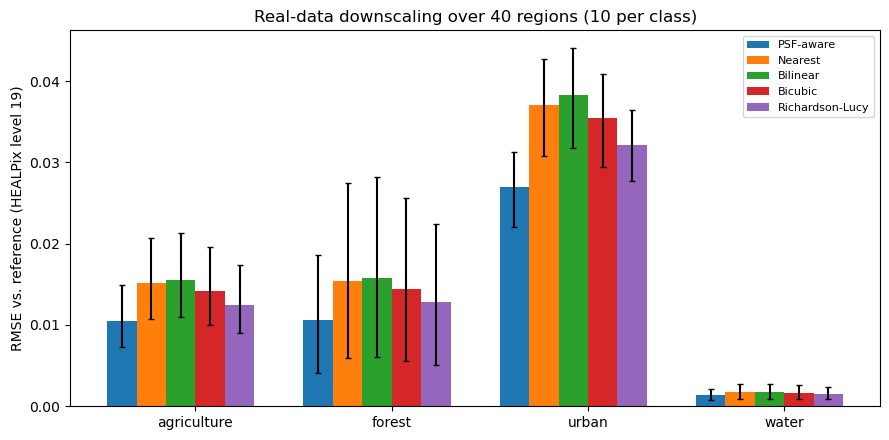

In [16]:
methods = ["psf_aware", "classical_nearest", "classical_linear",
           "classical_cubic", "richardson_lucy"]
labels = {"psf_aware": "PSF-aware", "classical_nearest": "Nearest",
          "classical_linear": "Bilinear", "classical_cubic": "Bicubic",
          "richardson_lucy": "Richardson-Lucy"}
classes = sorted(summary.scene_class.unique())

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.15
x = np.arange(len(classes))
for i, m in enumerate(methods):
    sub = summary[summary.method == m].set_index("scene_class")
    vals = [sub.loc[c, "mean_rmse"] if c in sub.index else np.nan for c in classes]
    lo = [sub.loc[c, "mean_rmse"] - sub.loc[c, "rmse_ci95_low"] if c in sub.index else 0 for c in classes]
    hi = [sub.loc[c, "rmse_ci95_high"] - sub.loc[c, "mean_rmse"] if c in sub.index else 0 for c in classes]
    ax.bar(x + (i - len(methods) / 2) * width, vals, width,
           yerr=[lo, hi], capsize=2, label=labels[m])
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel(f"RMSE vs. reference (HEALPix level {gt.REF_LEVEL})")
ax.set_title("Real-data downscaling over 40 regions (10 per class)")
ax.legend(fontsize=8)
fig.tight_layout()
gt.FIG_DIR.mkdir(exist_ok=True)
fig.savefig(gt.FIG_DIR / "real_groundtruth_multiregion_rmse.pdf", dpi=200)


## Width-mismatch sweep (real-data analogue of the synthetic mismatch arms)

The degradation stays at 25 m; only the **assumed** reconstruction width
changes. Only PSF-aware and Richardson--Lucy use that width, so the geometric
baselines are untouched by construction (the edge margin is pinned so all arms
score identical cells) -- any drift there would flag a footprint leak, not a
result.

**Why $\pm20\%$ matters and not just $\pm50\%$:** the spectral calibration of
the paper (Section IV-F) cannot distinguish the adopted 12.5 m response from
its $\pm20\%$ alternatives. The realistic uncertainty on an operational
effective response is therefore *of that order*. Testing only $\pm50\%$ leaves
the relevant interval unexamined: if the ranking already flips at $\pm20\%$,
the real-data advantage is fragile in practice; if it holds, the claim gains a
quantified safety margin between what the calibration bounds and where the
method breaks.

In [17]:
# Assumed-width sweep. 1.0 is the matched arm; 0.8/1.2 bracket the
# calibration uncertainty; 0.5/1.5 reproduce the severe arms already reported.
WIDTH_SCALES = [0.5, 0.8, 1.0, 1.2, 1.5]

frames = []
for s in WIDTH_SCALES:
    df = (gt.run_all(force=False) if s == 1.0
          else gt.run_width_mismatch(scale=s))
    frames.append(df[["scene", "method", "rmse"]].assign(scale=s))
sweep = pd.concat(frames, ignore_index=True)

# RMSE of every method at every assumed width, per scene
wide = sweep.pivot_table(index=["scene", "method"], columns="scale", values="rmse")
display(wide.round(4))

# Sanity: the geometric baselines must not move across arms (pinned footprint).
geo = sweep[sweep.method.str.startswith("classical")]
drift = geo.pivot_table(index=["scene", "method"], columns="scale", values="rmse")
max_drift = float((drift.max(axis=1) / drift.min(axis=1) - 1).max())
print(f"geometric-baseline drift across arms: {100 * max_drift:.2e} % "
      f"(anything visible would be a footprint leak, not a result)")

# Where does PSF-aware stop being best?
best = (sweep.loc[sweep.groupby(["scene", "scale"]).rmse.idxmin()]
        [["scene", "scale", "method", "rmse"]]
        .pivot_table(index="scene", columns="scale", values="method",
                     aggfunc="first"))
print("\nbest method per scene and assumed-width scale:")
display(best)

# Margin of PSF-aware over the best competitor (negative = PSF-aware loses)
rows = []
for (scene, s), grp in sweep.groupby(["scene", "scale"]):
    psf = grp.loc[grp.method == "psf_aware", "rmse"].iloc[0]
    other = grp.loc[grp.method != "psf_aware", "rmse"].min()
    rows.append({"scene": scene, "scale": s,
                 "margin_pct": 100 * (other - psf) / other})
margin = (pd.DataFrame(rows)
          .pivot_table(index="scene", columns="scale", values="margin_pct"))
print("\nPSF-aware margin over best competitor (%, negative = loses):")
display(margin.round(1))

out = gt.TABLE_DIR / "real_groundtruth_downscale_width_sweep.csv"
sweep.to_csv(out, index=False)
print(f"\nwritten {out}")


scale                             0.5     0.8     1.0     1.2     1.5
scene       method                                                   
agriculture classical_cubic    0.0112  0.0112  0.0112  0.0112  0.0112
            classical_linear   0.0128  0.0128  0.0128  0.0128  0.0128
            classical_nearest  0.0126  0.0126  0.0126  0.0126  0.0126
            psf_aware          0.0118  0.0089  0.0074  0.0075  0.0116
            richardson_lucy    0.0112  0.0102  0.0085  0.0073  0.0126
forest      classical_cubic    0.0127  0.0127  0.0127  0.0127  0.0127
            classical_linear   0.0141  0.0141  0.0141  0.0141  0.0141
            classical_nearest  0.0137  0.0137  0.0137  0.0137  0.0137
            psf_aware          0.0129  0.0104  0.0090  0.0090  0.0129
            richardson_lucy    0.0130  0.0121  0.0106  0.0095  0.0144
urban       classical_cubic    0.0353  0.0353  0.0353  0.0353  0.0353
            classical_linear   0.0377  0.0377  0.0377  0.0377  0.0377
            classical_nearest  0.0364  0.0364  0.0364  0.0364  0.0364
            psf_aware          0.0349  0.0303  0.0272  0.0270  0.0347
            richardson_lucy    0.0389  0.0376  0.0354  0.0336  0.0382
water       classical_cubic    0.0113  0.0113  0.0113  0.0113  0.0113
            classical_linear   0.0121  0.0121  0.0121  0.0121  0.0121
            classical_nearest  0.0117  0.0117  0.0117  0.0117  0.0117
            psf_aware          0.0113  0.0099  0.0090  0.0089  0.0111
            richardson_lucy    0.0118  0.0112  0.0104  0.0097  0.0115

geometric-baseline drift across arms: 2.21e-06 % (anything visible would be a footprint leak, not a result)

best method per scene and assumed-width scale:


scale,0.5,0.8,1.0,1.2,1.5
scene,,,,,
agriculture,richardson_lucy,psf_aware,psf_aware,richardson_lucy,classical_cubic
forest,classical_cubic,psf_aware,psf_aware,psf_aware,classical_cubic
urban,psf_aware,psf_aware,psf_aware,psf_aware,psf_aware
water,psf_aware,psf_aware,psf_aware,psf_aware,psf_aware



PSF-aware margin over best competitor (%, negative = loses):


scale,0.5,0.8,1.0,1.2,1.5
scene,,,,,
agriculture,-5.2,13.0,13.0,-2.4,-3.3
forest,-1.8,13.7,14.7,5.1,-1.6
urban,1.0,14.0,23.0,19.5,1.7
water,0.2,12.2,13.5,7.8,2.2



written tables/real_groundtruth_downscale_width_sweep.csv


## Notes

- Every result-changing setting (`REF_LEVEL`, `BLOCK`, `RECON_FWHM_M`,
  `MAX_ITER`, `REFERENCE_MODE`, `BASELINE_ESTIMAND`, degradation mode) is
  encoded in the cache and CSV filenames via `gt._cache_suffix()`, so variants
  never overwrite each other or the four-scene result the paper's Table VI is
  built from.
- `gt.run_multiregion()` skips a region only when its patch is missing or its
  reference is degenerate. Both criteria are evaluated before any method is
  scored.
- To rerun everything from scratch, pass `force=True`; otherwise cached
  intermediate `.npz` files are reused.

## Align the synthetic validation to the same regions

Sentinel-2 availability decides which regions survive, for reasons unrelated
to the method: catalogue coverage, cloud, granule edges. Comparing a
40-region synthetic result against a smaller real one would leave open whether
a difference comes from the method or from the two experiments sitting on
different sites.

Filtering the synthetic run to the regions that also produced a usable real
patch removes that question. Absolute RMSE still is not comparable between the
two -- the synthetic experiment recovers a known latent texture, the real one
an independently built HEALPix reference -- but the **ranking and the paired
margin over a common set of sites** are.

In [18]:
aligned_synthetic, real_regions = gt.align_synthetic_to_real(metrics)
side_by_side = gt.compare_real_and_synthetic(metrics, aligned_synthetic)
display(side_by_side)


Synthetic aligned to the real sample: 38/40 regions kept.
  2 synthetic-only region(s) dropped (no usable Sentinel-2 patch): nile_delta, western_australia
  per class: {'agriculture': 8, 'forest': 10, 'urban': 10, 'water': 10}


,source,competitor,n_regions,psf_aware_wins,win_fraction,mean_delta_rmse
0,synthetic,classical_cubic,38,38,1.0,0.010637
1,synthetic,classical_linear,38,38,1.0,0.014216
2,synthetic,classical_nearest,38,38,1.0,0.012651
3,real,classical_cubic,38,38,1.0,0.004092
4,real,classical_linear,38,38,1.0,0.005499
5,real,classical_nearest,38,38,1.0,0.005010
6,real,richardson_lucy,38,38,1.0,0.002418


## Publish the paper assets

`tex/figures/` and `tex/tables/` are separate copies of what this notebook
writes. Publishing them here keeps the compiled paper in step with the last
run instead of relying on a manual copy.

In [19]:
# Publish notebook outputs into tex/figures and tex/tables.
#
# Loaded by file path rather than by `import`: the module lives in the same
# repository as this notebook, but a checkout that has not been synced yet
# would otherwise fail with a bare ModuleNotFoundError at the very end of a
# long run. Here a missing file says so, and says where it should be.
import importlib.util
from pathlib import Path


def _repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "healpix_resample").is_dir() and (c / "notebooks").is_dir():
            return c
    raise RuntimeError(f"healpix-resample checkout not found above {p}")


_pub = _repo_root() / "notebooks" / "publish_paper_assets.py"
if not _pub.exists():
    print(f"publish_paper_assets.py not found at {_pub}\n"
          f"Nothing was published: tex/figures and tex/tables still hold the\n"
          f"previous run's assets. Sync the repository, then re-run this cell,\n"
          f"or from the repository root:\n"
          f"    python notebooks/publish_paper_assets.py")
else:
    _spec = importlib.util.spec_from_file_location("publish_paper_assets", _pub)
    _mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    _mod.publish()


publish_paper_assets: 13 figures cited by main.tex, 22 declared table CSVs
  updated        : 1
      figures/real_groundtruth_multiregion_paired.pdf
  up-to-date     : 33
  missing-source : 1
      figures/fig01_psf_healpix_workflow.pdf

  NOTE: a missing source means the paper cites an asset no notebook has produced yet (or it lives elsewhere). Re-run the notebook that writes it, then call publish() again.

  tex/ was out of date and has been refreshed -- recompile the paper.
